# NLP Assignment — Text Classification using Naive Bayes and Sentiment Analysis

## Objective
The objective of this assignment is to perform text classification on blog posts using the **Naive Bayes** algorithm and perform **sentiment analysis** on the blog text.

Dataset used: `blogs.csv`

Columns:
- `Data`: Blog text/content
- `Labels`: Blog category

This notebook includes:

1. Data loading  
2. Exploratory Data Analysis  
3. Text preprocessing  
4. Stopword removal  
5. TF-IDF feature extraction  
6. Naive Bayes model building  
7. Model evaluation using accuracy, precision, recall, and F1-score  
8. Sentiment analysis  
9. Sentiment distribution by category  
10. Final findings and conclusion

## 1. Install Required Libraries

In [6]:
# Run this cell only if libraries are missing
!pip install pandas numpy matplotlib seaborn scikit-learn nltk textblob

## 2. Import Required Libraries

In [7]:
# Basic libraries
import pandas as pd
import numpy as np

# Text processing
import re
import string

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and ML libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Stopwords
import nltk
from nltk.corpus import stopwords

# Sentiment analysis
from textblob import TextBlob

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Download NLTK Stopwords

In [8]:
# Download stopwords if not already available
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

print("Number of stopwords:", len(stop_words))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aryan\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


Number of stopwords: 198


## 4. Load Dataset

In [9]:
df = pd.read_csv("blogs.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (2000, 2)


,Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism


## 5. Dataset Information

The dataset contains two columns:

- `Data`: Blog text
- `Labels`: Category of the blog

In [10]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Data    2000 non-null   object
 1   Labels  2000 non-null   object
dtypes: object(2)
memory usage: 31.4+ KB

Column Names:
['Data', 'Labels']


## 6. Missing Values and Duplicate Check

In [11]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Drop missing values if any
df = df.dropna()

# Drop duplicate rows if any
df = df.drop_duplicates()

print("\nShape after cleaning missing/duplicate rows:", df.shape)

Missing Values:
Data      0
Labels    0
dtype: int64

Duplicate Rows: 0

Shape after cleaning missing/duplicate rows: (2000, 2)


## 7. Category Distribution

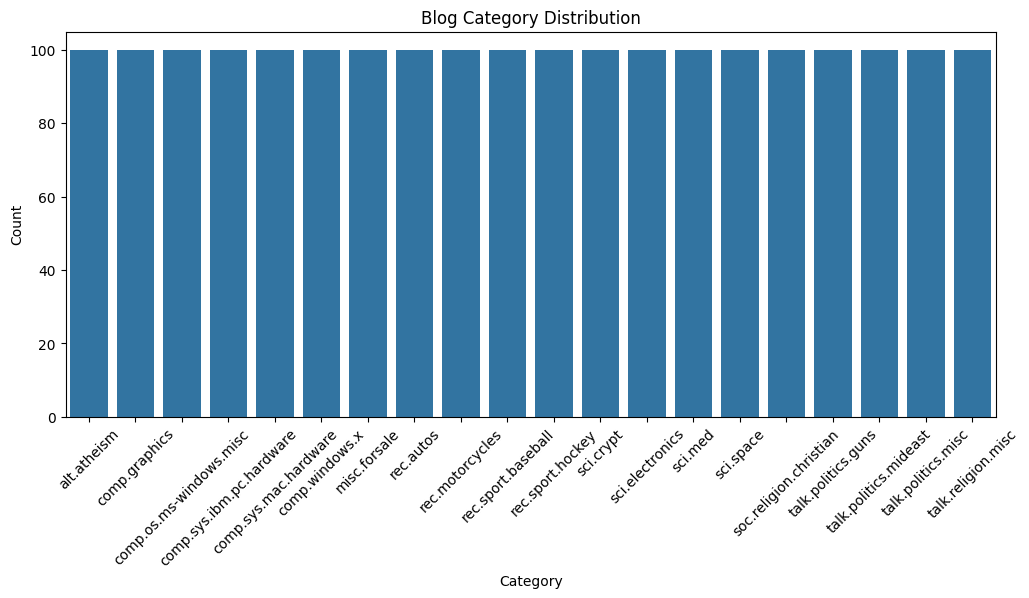

Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.christian      100
talk.politics.guns          100
talk.politics.mideast       100
talk.politics.misc          100
talk.religion.misc          100
Name: count, dtype: int64


In [12]:
plt.figure(figsize=(12,5))
sns.countplot(data=df, x="Labels", order=df["Labels"].value_counts().index)
plt.title("Blog Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

print(df["Labels"].value_counts())

## 8. Text Length Analysis

,Data,Labels,text_length,word_count
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,5972,910
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,1336,163
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,3116,450
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,15910,2732
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,3264,438


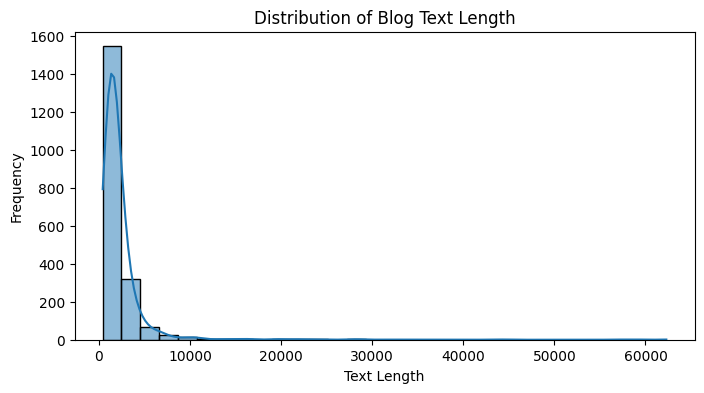

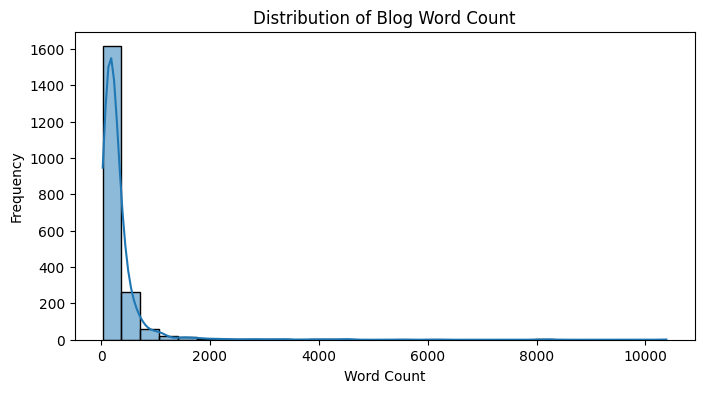

In [13]:
df["text_length"] = df["Data"].astype(str).apply(len)
df["word_count"] = df["Data"].astype(str).apply(lambda x: len(x.split()))

display(df[["Data", "Labels", "text_length", "word_count"]].head())

plt.figure(figsize=(8,4))
sns.histplot(df["text_length"], bins=30, kde=True)
plt.title("Distribution of Blog Text Length")
plt.xlabel("Text Length")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Distribution of Blog Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

## 9. Average Word Count by Category

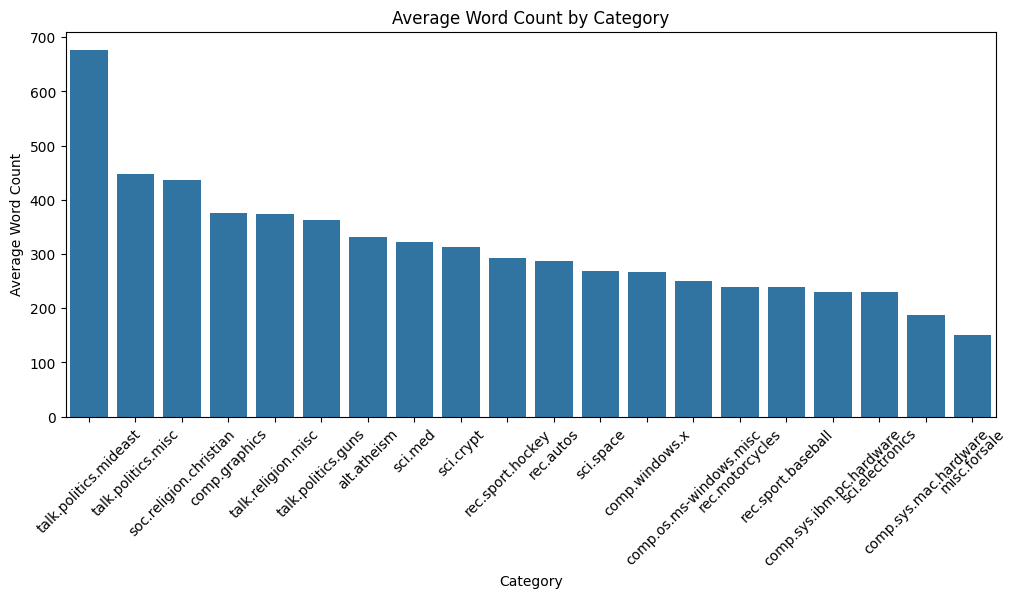

Labels
talk.politics.mideast       676.34
talk.politics.misc          447.59
soc.religion.christian      436.40
comp.graphics               374.98
talk.religion.misc          373.98
talk.politics.guns          362.80
alt.atheism                 330.36
sci.med                     322.45
sci.crypt                   313.17
rec.sport.hockey            293.37
rec.autos                   287.57
sci.space                   269.32
comp.windows.x              267.37
comp.os.ms-windows.misc     250.82
rec.motorcycles             238.85
rec.sport.baseball          238.47
comp.sys.ibm.pc.hardware    230.42
sci.electronics             230.36
comp.sys.mac.hardware       188.15
misc.forsale                150.55
Name: word_count, dtype: float64

In [14]:
avg_word_count = df.groupby("Labels")["word_count"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,5))
sns.barplot(x=avg_word_count.index, y=avg_word_count.values)
plt.title("Average Word Count by Category")
plt.xlabel("Category")
plt.ylabel("Average Word Count")
plt.xticks(rotation=45)
plt.show()

display(avg_word_count)

# 10. Text Preprocessing

Text preprocessing includes:

1. Convert text to lowercase  
2. Remove punctuation  
3. Remove numbers  
4. Remove extra spaces  
5. Remove stopwords

In [15]:
def clean_text(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Data"] = df["Data"].apply(clean_text)

display(df[["Data", "Cleaned_Data", "Labels"]].head())

,Data,Cleaned_Data,Labels
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...,alt.atheism
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,newsgroups altatheism path cantaloupesrvcscmue...,alt.atheism
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,path cantaloupesrvcscmuedudasnewsharvardedunoc...,alt.atheism
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,path cantaloupesrvcscmuedumagnesiumclubcccmued...,alt.atheism
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,xref cantaloupesrvcscmuedu altatheism talkreli...,alt.atheism


## 11. Most Frequent Words After Cleaning

,Word,Frequency
0,subject,2170
1,lines,2087
2,date,2083
3,path,2046
4,newsgroups,2040
5,messageid,2006
6,organization,1980
7,apr,1949
8,gmt,1787
9,one,1592


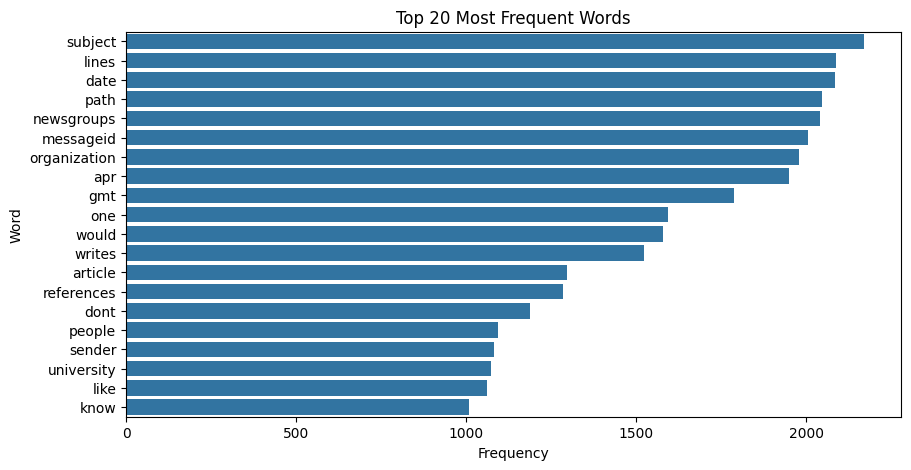

In [16]:
from collections import Counter

all_words = " ".join(df["Cleaned_Data"]).split()
word_freq = Counter(all_words)

common_words = pd.DataFrame(word_freq.most_common(20), columns=["Word", "Frequency"])

display(common_words)

plt.figure(figsize=(10,5))
sns.barplot(data=common_words, x="Frequency", y="Word")
plt.title("Top 20 Most Frequent Words")
plt.show()

# 12. Feature Extraction using TF-IDF

TF-IDF converts text into numerical features.

It gives higher importance to words that are frequent in one document but not common across all documents.

In [17]:
X = df["Cleaned_Data"]
y = df["Labels"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget Classes:")
print(y.unique())

X shape: (2000,)
y shape: (2000,)

Target Classes:
['alt.atheism' 'comp.graphics' 'comp.os.ms-windows.misc'
 'comp.sys.ibm.pc.hardware' 'comp.sys.mac.hardware' 'comp.windows.x'
 'misc.forsale' 'rec.autos' 'rec.motorcycles' 'rec.sport.baseball'
 'rec.sport.hockey' 'sci.crypt' 'sci.electronics' 'sci.med' 'sci.space'
 'soc.religion.christian' 'talk.politics.guns' 'talk.politics.mideast'
 'talk.politics.misc' 'talk.religion.misc']


## 13. Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1600,)
X_test shape: (400,)
y_train shape: (1600,)
y_test shape: (400,)


# 14. Naive Bayes Model for Text Classification

We use a pipeline containing:

1. TF-IDF Vectorizer  
2. Multinomial Naive Bayes Classifier  

Multinomial Naive Bayes is commonly used for text classification problems.

In [19]:
nb_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("classifier", MultinomialNB())
])

nb_model.fit(X_train, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


## 15. Model Prediction

In [20]:
y_pred = nb_model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
['sci.crypt' 'sci.med' 'talk.politics.mideast' 'soc.religion.christian'
 'talk.politics.guns' 'sci.med' 'comp.windows.x' 'rec.motorcycles'
 'talk.politics.mideast' 'comp.graphics']


# 16. Model Evaluation

Evaluation metrics used:

- Accuracy
- Precision
- Recall
- F1-score

In [21]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Naive Bayes Model Evaluation")
print("----------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Naive Bayes Model Evaluation
----------------------------
Accuracy : 0.88
Precision: 0.8887
Recall   : 0.88
F1 Score : 0.8798

Classification Report:
                          precision    recall  f1-score   support

             alt.atheism       0.81      0.65      0.72        20
           comp.graphics       0.90      0.90      0.90        20
 comp.os.ms-windows.misc       0.90      0.95      0.93        20
comp.sys.ibm.pc.hardware       0.70      0.80      0.74        20
   comp.sys.mac.hardware       0.95      0.90      0.92        20
          comp.windows.x       0.94      0.85      0.89        20
            misc.forsale       1.00      0.90      0.95        20
               rec.autos       0.95      0.95      0.95        20
         rec.motorcycles       0.91      1.00      0.95        20
      rec.sport.baseball       1.00      1.00      1.00        20
        rec.sport.hockey       1.00      1.00      1.00        20
               sci.crypt       0.95      1.00      0.98  

## 17. Confusion Matrix

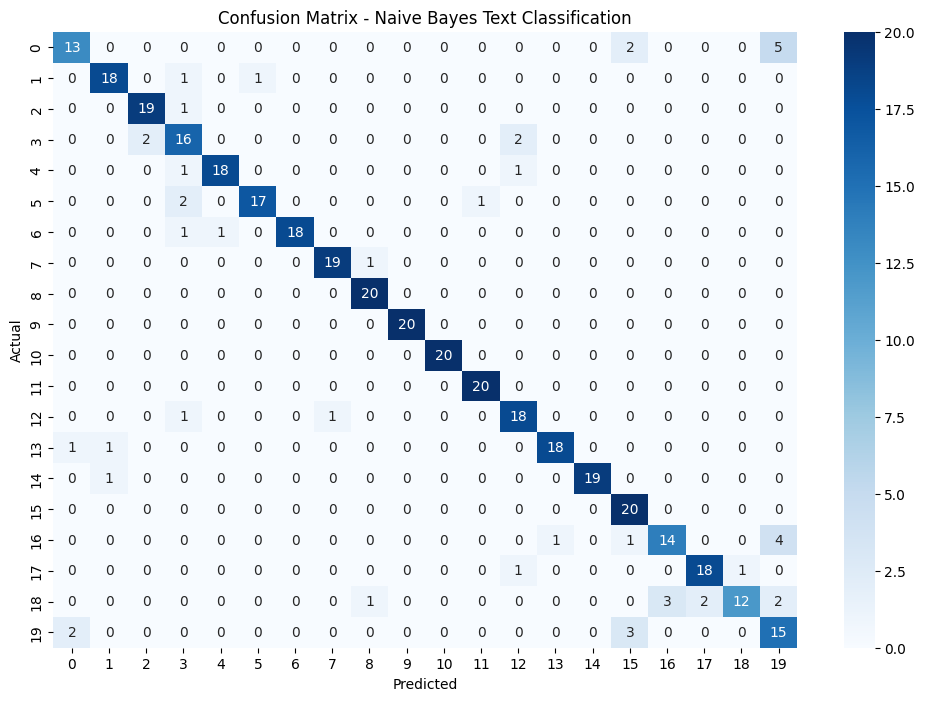

In [22]:
plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes Text Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 18. Sentiment Analysis

We use TextBlob to calculate sentiment polarity.

Polarity ranges from -1 to +1:

- Positive polarity: positive sentiment
- Negative polarity: negative sentiment
- Near zero polarity: neutral sentiment

In [23]:
def get_sentiment_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_sentiment_label(polarity):
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment_Polarity"] = df["Data"].apply(get_sentiment_polarity)
df["Sentiment"] = df["Sentiment_Polarity"].apply(get_sentiment_label)

display(df[["Data", "Labels", "Sentiment_Polarity", "Sentiment"]].head())

,Data,Labels,Sentiment_Polarity,Sentiment
0,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,0.072213,Positive
1,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,alt.atheism,-0.053757,Negative
2,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,alt.atheism,0.093119,Positive
3,Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...,alt.atheism,0.055008,Positive
4,Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...,alt.atheism,0.132183,Positive


## 19. Overall Sentiment Distribution

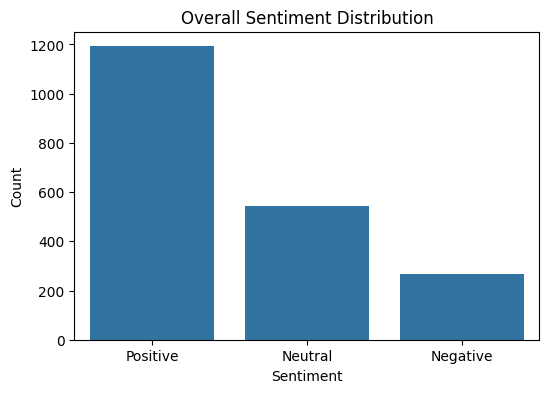

Sentiment
Positive    1192
Neutral      542
Negative     266
Name: count, dtype: int64

Sentiment Percentage:
Sentiment
Positive    59.6
Neutral     27.1
Negative    13.3
Name: proportion, dtype: float64


In [24]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Sentiment", order=["Positive", "Neutral", "Negative"])
plt.title("Overall Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

print(df["Sentiment"].value_counts())
print("\nSentiment Percentage:")
print(df["Sentiment"].value_counts(normalize=True) * 100)

## 20. Sentiment Distribution Across Categories

Sentiment,Negative,Neutral,Positive
Labels,,,
alt.atheism,12,28,60
comp.graphics,15,25,60
comp.os.ms-windows.misc,17,19,64
comp.sys.ibm.pc.hardware,12,27,61
comp.sys.mac.hardware,12,24,64
comp.windows.x,17,27,56
misc.forsale,13,21,66
rec.autos,11,20,69
rec.motorcycles,14,24,62


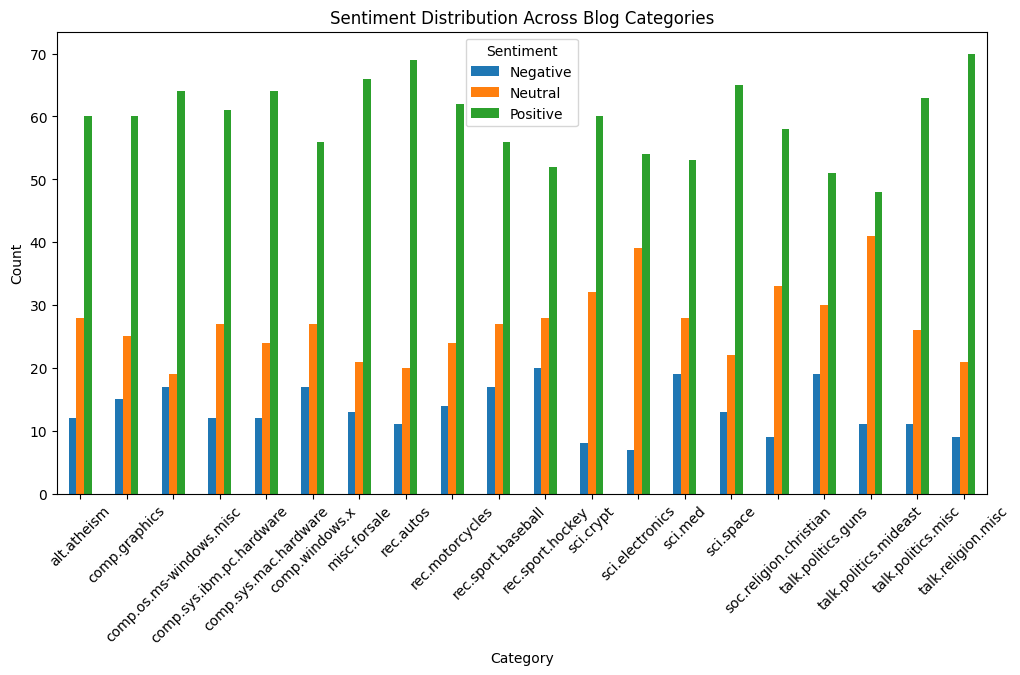

In [25]:
sentiment_category = pd.crosstab(df["Labels"], df["Sentiment"])

display(sentiment_category)

sentiment_category.plot(kind="bar", figsize=(12,6))
plt.title("Sentiment Distribution Across Blog Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

## 21. Percentage Sentiment Distribution by Category

Sentiment,Negative,Neutral,Positive
Labels,,,
alt.atheism,12.0,28.0,60.0
comp.graphics,15.0,25.0,60.0
comp.os.ms-windows.misc,17.0,19.0,64.0
comp.sys.ibm.pc.hardware,12.0,27.0,61.0
comp.sys.mac.hardware,12.0,24.0,64.0
comp.windows.x,17.0,27.0,56.0
misc.forsale,13.0,21.0,66.0
rec.autos,11.0,20.0,69.0
rec.motorcycles,14.0,24.0,62.0


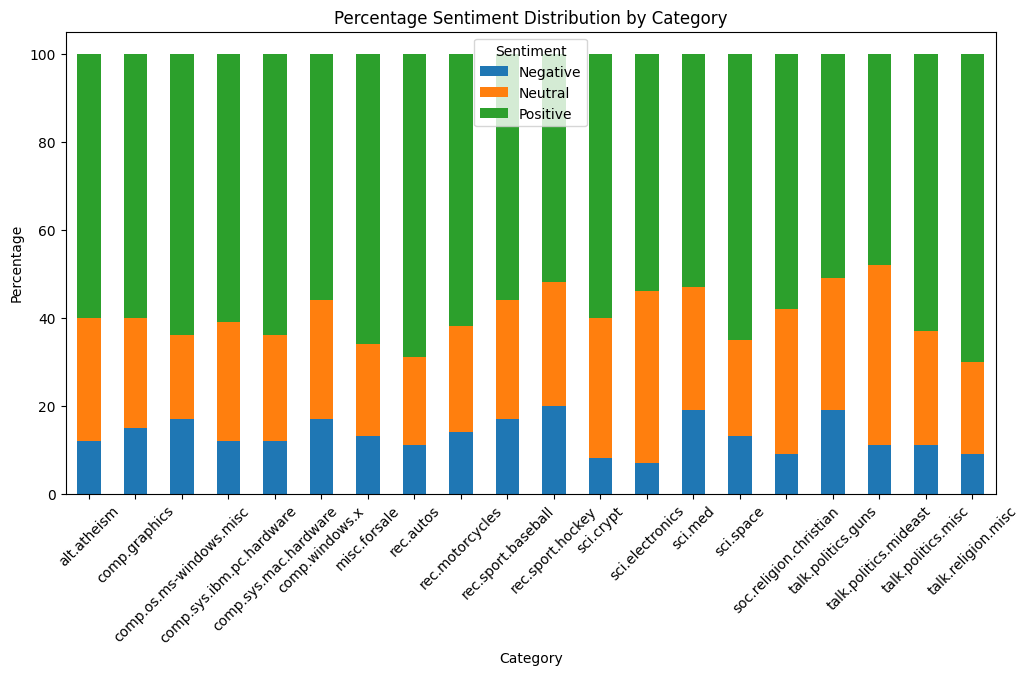

In [26]:
sentiment_category_percentage = pd.crosstab(
    df["Labels"],
    df["Sentiment"],
    normalize="index"
) * 100

display(sentiment_category_percentage)

sentiment_category_percentage.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Percentage Sentiment Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.legend(title="Sentiment")
plt.show()

## 22. Average Sentiment Polarity by Category

Labels
misc.forsale                0.122558
talk.religion.misc          0.083906
comp.sys.mac.hardware       0.080219
rec.autos                   0.078978
rec.motorcycles             0.078685
sci.electronics             0.077250
comp.sys.ibm.pc.hardware    0.075935
alt.atheism                 0.075598
soc.religion.christian      0.074055
comp.os.ms-windows.misc     0.073636
comp.graphics               0.070921
sci.space                   0.070903
rec.sport.baseball          0.069712
talk.politics.misc          0.069623
comp.windows.x              0.066120
sci.crypt                   0.065158
talk.politics.mideast       0.050261
rec.sport.hockey            0.048446
sci.med                     0.042443
talk.politics.guns          0.039497
Name: Sentiment_Polarity, dtype: float64

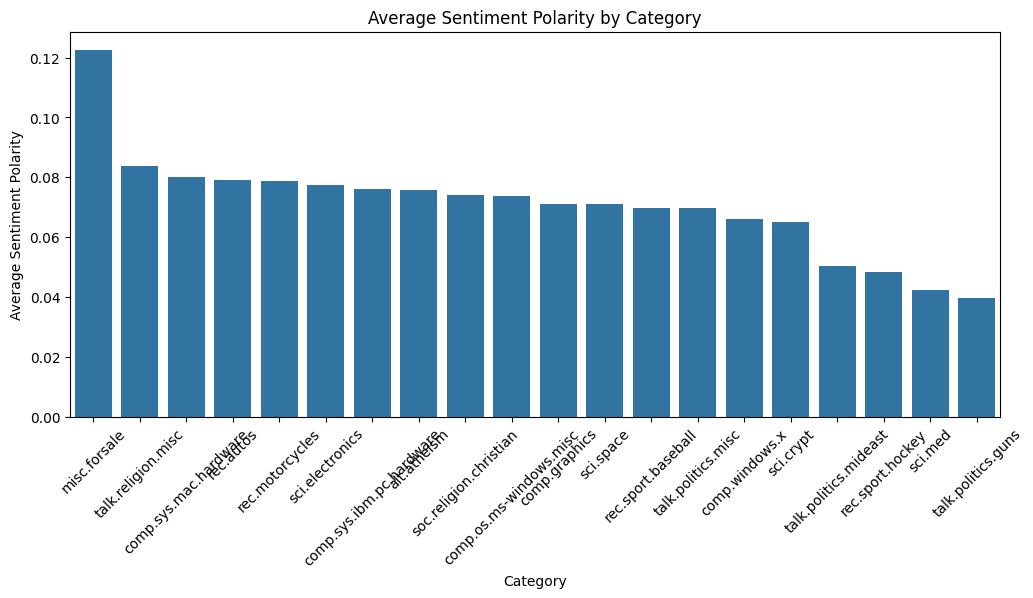

In [27]:
avg_sentiment = df.groupby("Labels")["Sentiment_Polarity"].mean().sort_values(ascending=False)

display(avg_sentiment)

plt.figure(figsize=(12,5))
sns.barplot(x=avg_sentiment.index, y=avg_sentiment.values)
plt.title("Average Sentiment Polarity by Category")
plt.xlabel("Category")
plt.ylabel("Average Sentiment Polarity")
plt.xticks(rotation=45)
plt.show()

## 23. Sample Sentiment Outputs

In [28]:
display(df[["Labels", "Data", "Sentiment_Polarity", "Sentiment"]].sample(10, random_state=42))

,Labels,Data,Sentiment_Polarity,Sentiment
1860,talk.politics.misc,Xref: cantaloupe.srv.cs.cmu.edu misc.headlines...,0.091369,Positive
353,comp.sys.ibm.pc.hardware,Newsgroups: comp.sys.ibm.pc.hardware\nPath: ca...,0.141414,Positive
1333,sci.med,Xref: cantaloupe.srv.cs.cmu.edu sci.energy:156...,0.033968,Neutral
905,rec.sport.baseball,Newsgroups: rec.sport.baseball\nPath: cantalou...,0.212381,Positive
1289,sci.electronics,Newsgroups: sci.electronics\nPath: cantaloupe....,0.229167,Positive
1273,sci.electronics,Newsgroups: sci.electronics\nPath: cantaloupe....,0.087685,Positive
938,rec.sport.baseball,Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...,-0.052604,Negative
1731,talk.politics.mideast,Xref: cantaloupe.srv.cs.cmu.edu talk.politics....,0.119063,Positive
65,alt.atheism,Newsgroups: alt.atheism\nPath: cantaloupe.srv....,0.094485,Positive
1323,sci.med,Newsgroups: sci.med\nPath: cantaloupe.srv.cs.c...,0.068769,Positive


# 24. Discussion of Results

## Naive Bayes Classification

Naive Bayes is suitable for text classification because it works well with word frequency-based features such as TF-IDF. It is fast, simple, and effective for categorizing documents.

Possible challenges:
1. Text data can contain noise.
2. Some categories may share similar vocabulary.
3. Naive Bayes assumes feature independence, which is not always true in real text.
4. Class imbalance can affect performance.
5. Short texts may not provide enough information for correct classification.

## Sentiment Analysis

Sentiment analysis helps understand the emotional tone of blog posts.

Positive sentiment indicates favorable or optimistic content.  
Negative sentiment indicates critical or unfavorable content.  
Neutral sentiment indicates factual or balanced content.

Category-wise sentiment analysis helps identify which blog themes contain more positive, negative, or neutral language.

# 25. Final Conclusion

In this assignment, blog post text classification was performed using the Naive Bayes algorithm. The dataset was loaded and explored to understand category distribution, text length, and word count. Text preprocessing was applied by converting text to lowercase, removing punctuation, numbers, URLs, HTML tags, extra spaces, and stopwords.

TF-IDF was used to convert cleaned text into numerical features. A Multinomial Naive Bayes classifier was trained and evaluated using accuracy, precision, recall, and F1-score. The confusion matrix and classification report helped analyze the model's performance across different blog categories.

Sentiment analysis was performed on the blog text using TextBlob. Each blog was categorized as positive, negative, or neutral based on sentiment polarity. The distribution of sentiments across different categories was visualized and analyzed.

Overall, this assignment demonstrates how Natural Language Processing techniques can be used for text classification and sentiment analysis in real-world blog datasets.

# 26. Complete Assignment Summary

## Steps Performed

1. Loaded the blogs dataset.
2. Checked missing values and duplicates.
3. Performed exploratory data analysis.
4. Cleaned the blog text.
5. Removed stopwords.
6. Extracted features using TF-IDF.
7. Built a Naive Bayes classifier.
8. Evaluated the model.
9. Performed sentiment analysis.
10. Visualized sentiment distribution.
11. Summarized findings and challenges.

## Libraries Used

- pandas
- numpy
- matplotlib
- seaborn
- nltk
- scikit-learn
- textblob